In [1]:
# ═══════════════════════════════════════════════════════
#  INDUSTRIAL FAULT CLASSIFICATION USING MACHINE LEARNING
#  Author: Oscar Vincent Dbritto
# ═══════════════════════════════════════════════════════
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, accuracy_score)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
 
plt.style.use("seaborn-v0_8-whitegrid")
print("All libraries loaded!")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")


All libraries loaded!
NumPy: 2.4.2, Pandas: 2.3.3
Scikit-learn: 1.8.0


In [2]:
np.random.seed(42)
n_samples = 2000
 
def generate_fault_data(n):
    """Simulate sensor data from an industrial motor with 4 conditions."""
    labels, data = [], []
    for _ in range(n):
        fault = np.random.choice(
            ["Normal", "Bearing Fault", "Rotor Fault", "Stator Fault"],
            p=[0.50, 0.20, 0.15, 0.15])
        
        temp = 65 + np.random.normal(0, 3)
        vibration = 1.2 + np.random.normal(0, 0.2)
        current = 12.5 + np.random.normal(0, 0.5)
        speed = 1480 + np.random.normal(0, 10)
        sound_db = 72 + np.random.normal(0, 2)
        power = 5.5 + np.random.normal(0, 0.3)
        
        if fault == "Bearing Fault":
            vibration += np.random.uniform(2.0, 5.0)
            temp += np.random.uniform(8, 20)
            sound_db += np.random.uniform(5, 15)
        elif fault == "Rotor Fault":
            vibration += np.random.uniform(1.0, 3.0)
            current += np.random.uniform(2, 6)
            speed -= np.random.uniform(30, 80)
            power += np.random.uniform(0.5, 2.0)
        elif fault == "Stator Fault":
            current += np.random.uniform(3, 8)
            temp += np.random.uniform(10, 25)
            power += np.random.uniform(1.0, 3.0)
        
        data.append([temp, vibration, current, speed, sound_db, power])
        labels.append(fault)
    
    cols = ["temperature_C", "vibration_mm_s", "current_A",
            "speed_rpm", "sound_dB", "power_kW"]
    return pd.DataFrame(data, columns=cols), labels
 
df, labels = generate_fault_data(n_samples)
df["fault_type"] = labels
 
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df["fault_type"].value_counts())
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (2000, 7)

Class distribution:
fault_type
Normal           958
Bearing Fault    420
Stator Fault     339
Rotor Fault      283
Name: count, dtype: int64

First 5 rows:


,temperature_C,vibration_mm_s,current_A,speed_rpm,sound_dB,power_kW,fault_type
0,61.664360,1.263780,12.639521,1490.105153,70.838244,5.342449,Normal
1,65.725887,0.817344,11.637541,1474.377125,69.974338,5.594274,Normal
2,62.889969,0.772076,12.185263,1485.977205,77.118976,5.618270,Normal
3,61.547019,1.275140,12.199681,1477.083063,70.796587,6.055683,Normal
4,63.399054,1.198894,12.385275,1483.893489,69.469762,5.827598,Normal


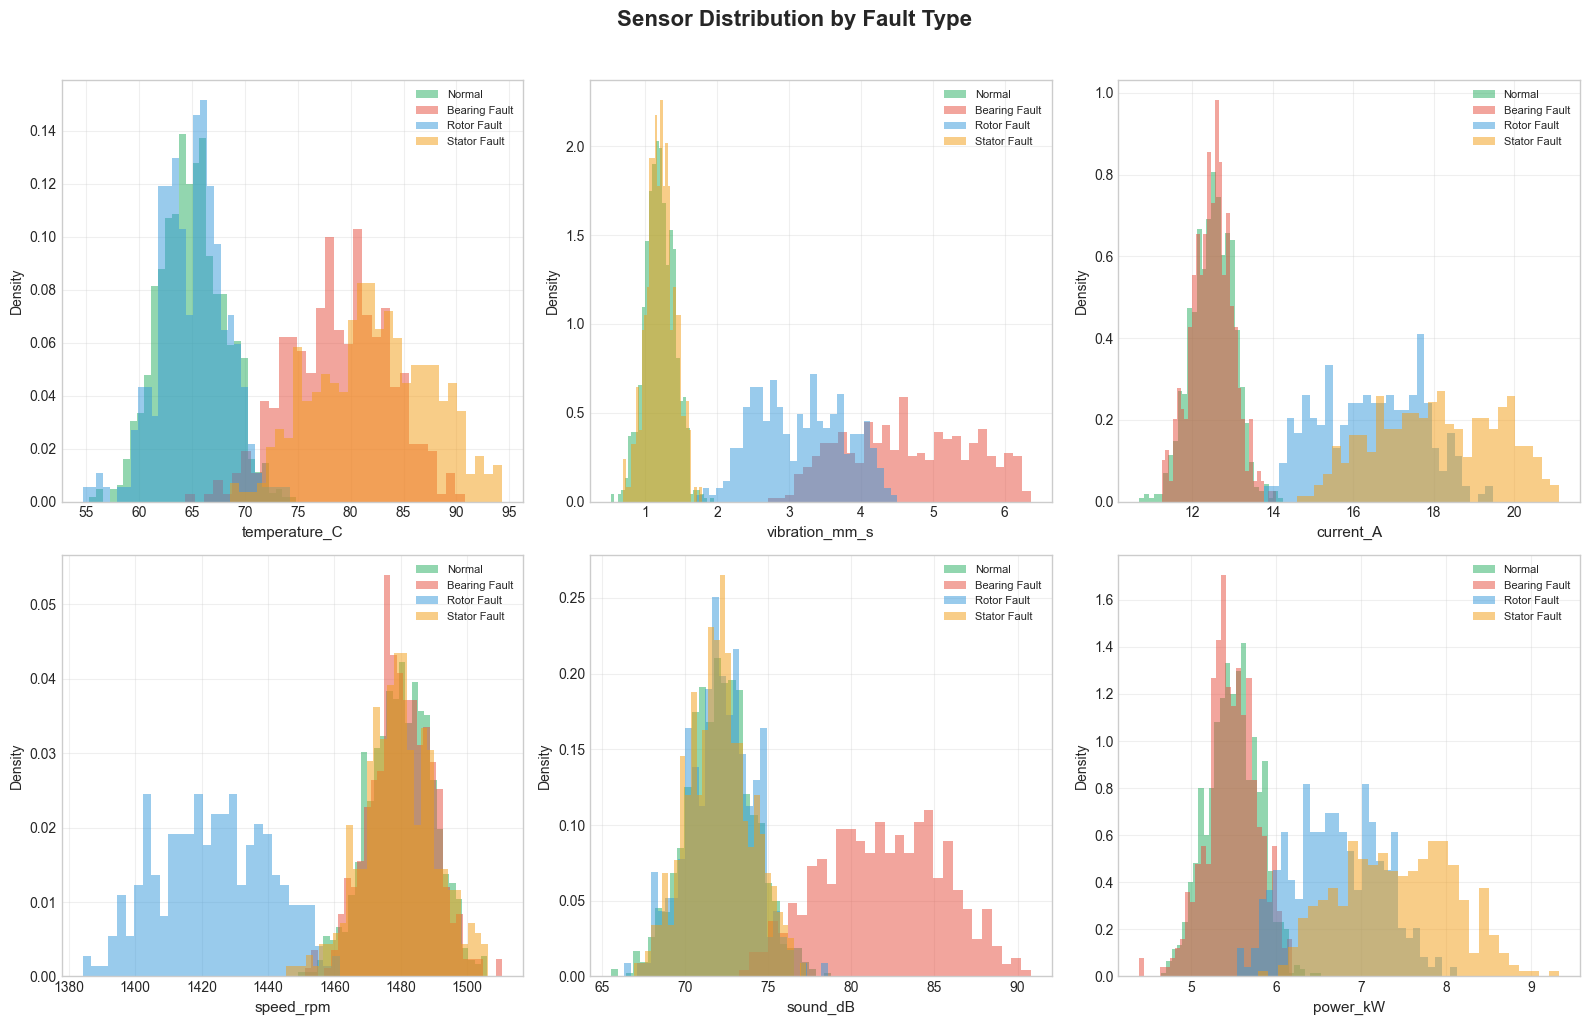

Saved: eda_distributions.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
sensors = ["temperature_C", "vibration_mm_s", "current_A",
           "speed_rpm", "sound_dB", "power_kW"]
colors = {"Normal": "#27AE60", "Bearing Fault": "#E74C3C",
          "Rotor Fault": "#3498DB", "Stator Fault": "#F39C12"}
 
for i, (sensor, ax) in enumerate(zip(sensors, axes.flat)):
    for fault, color in colors.items():
        subset = df[df["fault_type"] == fault]
        ax.hist(subset[sensor], bins=30, alpha=0.5,
                label=fault, color=color, density=True)
    ax.set_xlabel(sensor, fontsize=11)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
 
plt.suptitle("Sensor Distribution by Fault Type",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_distributions.png")


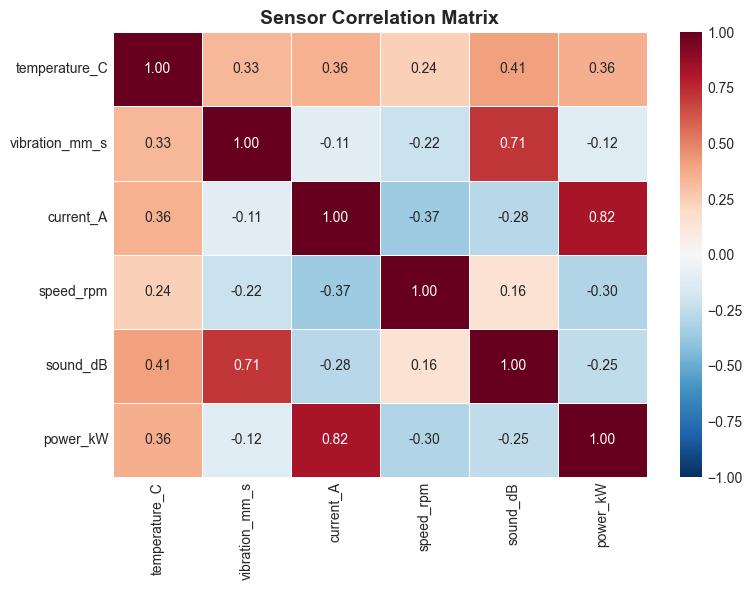

Saved: correlation_matrix.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[sensors].corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0,
            ax=ax, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Sensor Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: correlation_matrix.png")

In [5]:
X = df[sensors].values
le = LabelEncoder()
y = le.fit_transform(df["fault_type"])
class_names = le.classes_
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
 
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {X_train.shape[1]}")
print(f"Classes:      {list(class_names)}")
print(f"\nClass mapping: {dict(zip(class_names, range(len(class_names))))}")

Training set: 1600 samples
Test set:     400 samples
Features:     6
Classes:      [np.str_('Bearing Fault'), np.str_('Normal'), np.str_('Rotor Fault'), np.str_('Stator Fault')]

Class mapping: {np.str_('Bearing Fault'): 0, np.str_('Normal'): 1, np.str_('Rotor Fault'): 2, np.str_('Stator Fault'): 3}


In [6]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=42),
    "SVM (RBF kernel)": SVC(
        kernel="rbf", probability=True, random_state=42),
    "Neural Network (MLP)": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}
 
results = {}
print("Training 4 models...")
print(f"{'Model':<25} {'Accuracy':>10} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 58)
 
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X_train_sc, y_train, cv=5)
    results[name] = {"model": model, "accuracy": acc,
                     "cv_mean": cv.mean(), "cv_std": cv.std()}
    print(f"{name:<25} {acc:>10.4f} {cv.mean():>10.4f} {cv.std():>10.4f}")
 
best_name = max(results, key=lambda k: results[k]["accuracy"])
print(f"\n🏆 Best model: {best_name} "
      f"({results[best_name]['accuracy']:.4f})")


Training 4 models...
Model                       Accuracy    CV Mean     CV Std
----------------------------------------------------------
Random Forest                 1.0000     1.0000     0.0000
Gradient Boosting             1.0000     0.9975     0.0031
SVM (RBF kernel)              1.0000     1.0000     0.0000
Neural Network (MLP)          1.0000     1.0000     0.0000

🏆 Best model: Random Forest (1.0000)


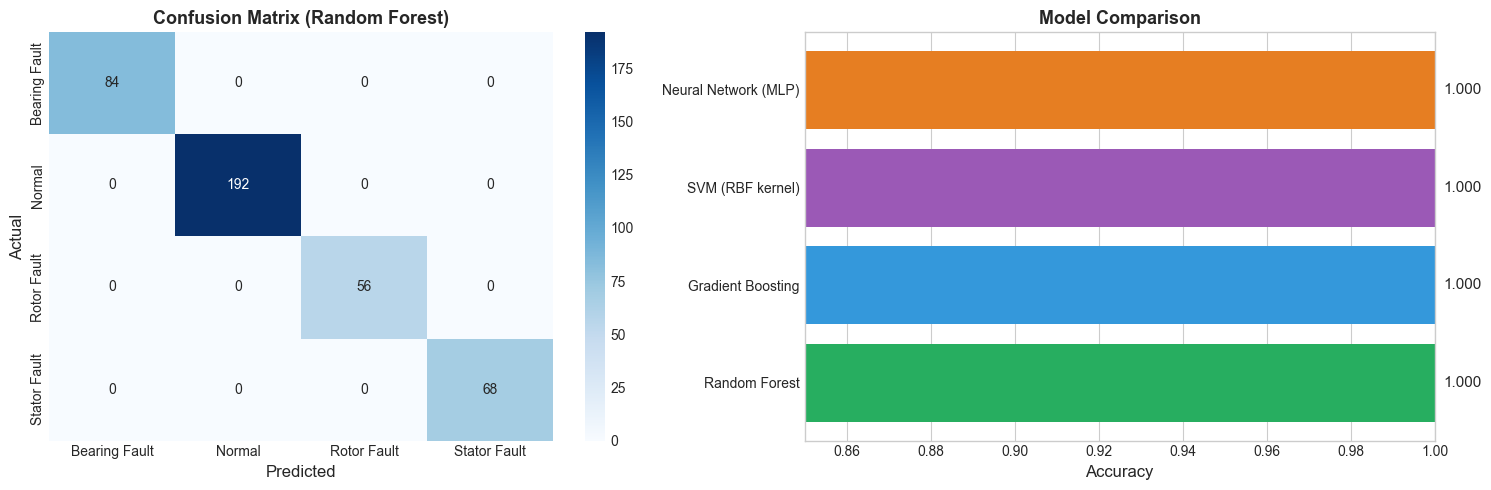


CLASSIFICATION REPORT
               precision    recall  f1-score   support

Bearing Fault       1.00      1.00      1.00        84
       Normal       1.00      1.00      1.00       192
  Rotor Fault       1.00      1.00      1.00        56
 Stator Fault       1.00      1.00      1.00        68

     accuracy                           1.00       400
    macro avg       1.00      1.00      1.00       400
 weighted avg       1.00      1.00      1.00       400



In [7]:
best = results[best_name]["model"]
y_pred = best.predict(X_test_sc)
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_xlabel("Predicted", fontsize=12)
ax1.set_ylabel("Actual", fontsize=12)
ax1.set_title(f"Confusion Matrix ({best_name})", fontsize=13, fontweight="bold")
 
names = list(results.keys())
accs = [results[n]["accuracy"] for n in names]
bars = ax2.barh(names, accs, color=["#27AE60", "#3498DB", "#9B59B6", "#E67E22"])
ax2.set_xlim(0.85, 1.0)
ax2.set_xlabel("Accuracy", fontsize=12)
ax2.set_title("Model Comparison", fontsize=13, fontweight="bold")
for bar, v in zip(bars, accs):
    ax2.text(v + 0.002, bar.get_y() + bar.get_height()/2,
             f"{v:.3f}", va="center", fontsize=11)
 
plt.tight_layout()
plt.savefig("confusion_and_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=class_names))

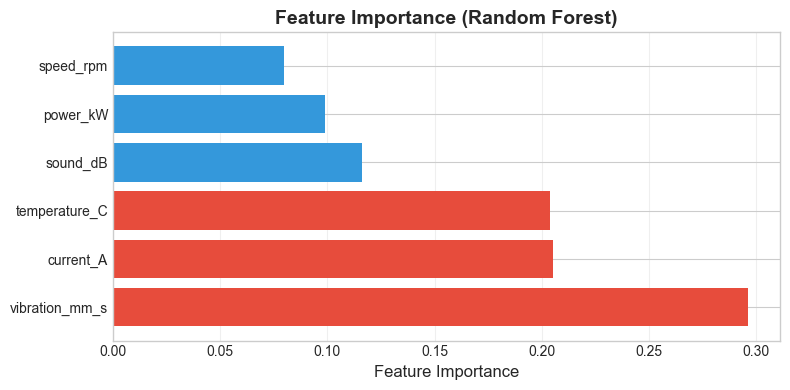

Feature ranking:
  vibration_mm_s      : 0.2963
  current_A           : 0.2052
  temperature_C       : 0.2038
  sound_dB            : 0.1162
  power_kW            : 0.0988
  speed_rpm           : 0.0796


In [8]:
if hasattr(best, "feature_importances_"):
    imp = best.feature_importances_
    idx = np.argsort(imp)[::-1]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    colors_fi = ["#E74C3C" if i < 3 else "#3498DB" for i in range(len(idx))]
    ax.barh([sensors[i] for i in idx], imp[idx], color=colors_fi)
    ax.set_xlabel("Feature Importance", fontsize=12)
    ax.set_title(f"Feature Importance ({best_name})",
                 fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print("Feature ranking:")
    for i in idx:
        print(f"  {sensors[i]:20s}: {imp[i]:.4f}")
else:
    print("Feature importance not available for", best_name)


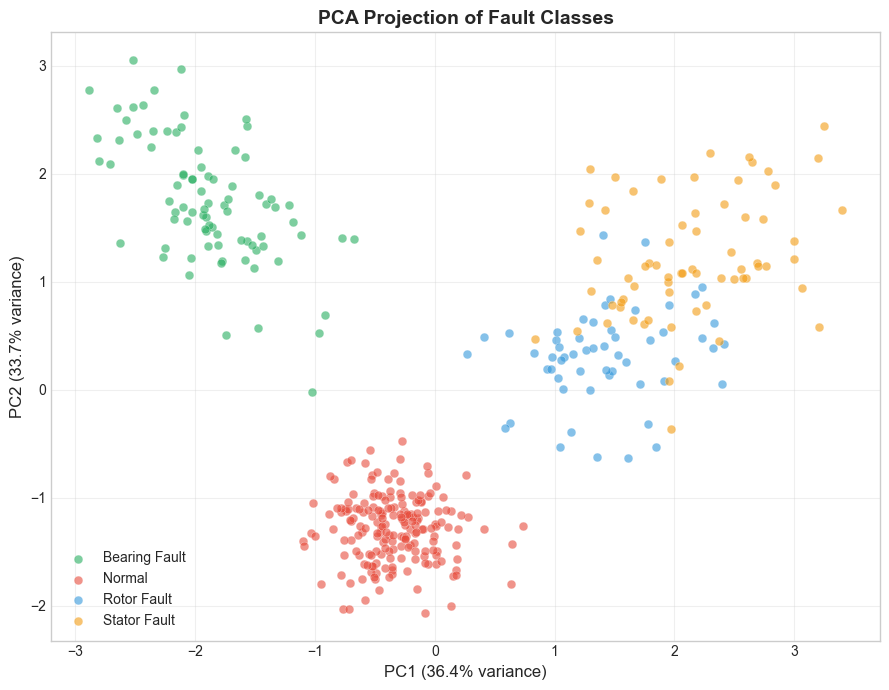

Explained variance: PC1=36.4%, PC2=33.7%


In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_sc)
 
fig, ax = plt.subplots(figsize=(9, 7))
scatter_colors = ["#27AE60", "#E74C3C", "#3498DB", "#F39C12"]
for i, fault in enumerate(class_names):
    mask = y_test == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=fault, alpha=0.6, s=40,
               color=scatter_colors[i], edgecolors="white", linewidth=0.3)
 
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
              fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
              fontsize=12)
ax.set_title("PCA Projection of Fault Classes",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")


In [10]:
print("=" * 60)
print("  INDUSTRIAL FAULT CLASSIFICATION – FINAL SUMMARY")
print("=" * 60)
print(f"  Dataset:      {n_samples} samples, 6 sensors, 4 fault classes")
print(f"  Best model:   {best_name}")
print(f"  Accuracy:     {results[best_name]['accuracy']:.4f}")
print(f"  CV score:     {results[best_name]['cv_mean']:.4f} "
      f"± {results[best_name]['cv_std']:.4f}")
print(f"")
print(f"  ML Pipeline Steps:")
print(f"    1. Data generation (simulated industrial motor sensors)")
print(f"    2. Exploratory data analysis (histograms, correlation)")
print(f"    3. Preprocessing (StandardScaler, LabelEncoder, 80/20 split)")
print(f"    4. Model training (RF, GBM, SVM-RBF, Neural Network MLP)")
print(f"    5. Evaluation (confusion matrix, classification report)")
print(f"    6. Feature importance ranking")
print(f"    7. Dimensionality reduction (PCA 2D visualization)")
print(f"")
print(f"  Built by Oscar Vincent Dbritto")
print("=" * 60)


  INDUSTRIAL FAULT CLASSIFICATION – FINAL SUMMARY
  Dataset:      2000 samples, 6 sensors, 4 fault classes
  Best model:   Random Forest
  Accuracy:     1.0000
  CV score:     1.0000 ± 0.0000

  ML Pipeline Steps:
    1. Data generation (simulated industrial motor sensors)
    2. Exploratory data analysis (histograms, correlation)
    3. Preprocessing (StandardScaler, LabelEncoder, 80/20 split)
    4. Model training (RF, GBM, SVM-RBF, Neural Network MLP)
    5. Evaluation (confusion matrix, classification report)
    6. Feature importance ranking
    7. Dimensionality reduction (PCA 2D visualization)

  Built by Oscar Vincent Dbritto
